# Stimulus pipeline

Everything related to stimulus presentation can be found inside [the stimulus pipeline](https://github.com/cajal/stimuli). During an inception loop experiment, you'd typically work with at least two kinds of stimulus: first set to obtain responses for network training and the second set that you generate using the trained network. Given this, it is critical that you become very familiar with how stimulus are designed, generated and presented in an experiment.

Here we'll take a brief look at the stimulus pipeline, focusing on tables that are most relevant for MEI like inception loop experiments. However keep in mind that you'll very likely have to create an entirely new class of stimulus if you would go beyond simple image or movie presentation.

In [4]:
import datajoint as dj

In [5]:
stimulus = dj.create_virtual_module('stimulus', 'pipeline_stimulus')

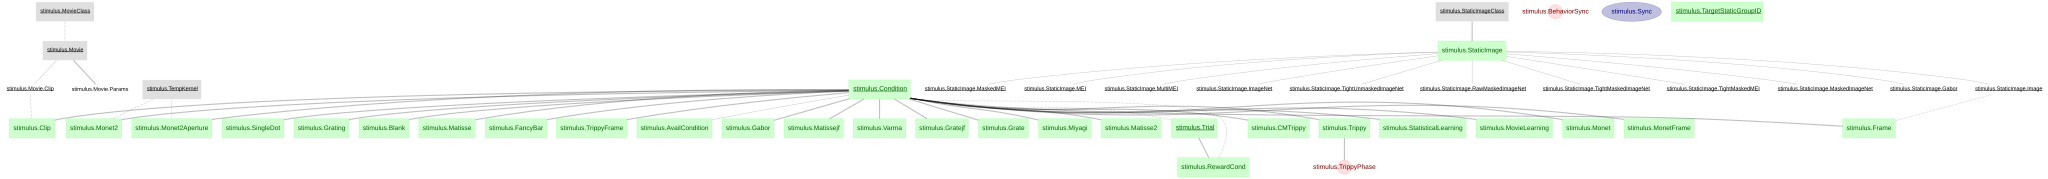

In [6]:
dj.ERD(stimulus)

The main work horse tables for the stimulus pipeline are `stimulus.Condition` and `stimulus.Trial`

`stimulus.Condition` enumerates every single possible stimulus condition (stimulus + any variable aspect of the presentation such as duration of blank period following the stimulus). As a result, it can get quite large.

In [9]:
stimulus.Condition()

condition_hash 120-bit hash (The first 20 chars of MD5 in base64),stimulus_type class name of the special stimulus condition table class,stimulus_version specified by the property `version` of the stimulus class
++01I5f0W5GLdbtlL6Pv,stimulus.Gratejf,2
++0nsGPrmM7MZdBkJwSk,stimulus.Frame,3
++0z1xDFeh+sfQvd1hsJ,stimulus.Clip,1
++17p6q/VdZYJyBOWFOT,stimulus.Clip,1
++2KgCgjPPSfWOdpAjH3,stimulus.Monet2Aperture,1
++2W7El2Q44xiO3Jf89L,stimulus.Frame,1
++3tQPRBlpY7qJVm3iDP,stimulus.Frame,3
++4SfEt3NvRFdbJZOPOB,stimulus.Frame,2
++5NXFtdkK9JyOQYxbQv,stimulus.Frame,3
++6ks6vk9UEZCUT6BvdR,stimulus.Matisse,2


And stimulus trial enumerates all "trials" in an experiment. Note that imaging data in principle do not have the concept of a trial -- this is something determined only by the stimulus onset/offset.

In [11]:
stimulus.Trial()

animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,trial_idx trial index within sessions,condition_hash 120-bit hash (The first 20 chars of MD5 in base64),flip_times (s) row array of flip times,last_flip the last flip number in this trial,trial_ts automatic
0,3,1,0,cXbeFDRGjmK6HmR5BSy6,=BLOB=,50062,2017-04-22 00:22:41
0,3,1,1,108EalmyOCQowSQz80Ne,=BLOB=,50065,2017-04-22 00:22:43
0,3,1,2,aR+FH+zeREMRVmMduDyB,=BLOB=,50067,2017-04-22 00:22:44
0,3,1,3,1RHkB6tab+fZvItjhbRp,=BLOB=,50069,2017-04-22 00:22:46
0,3,1,4,efPOQef/0isTy/CnsIk0,=BLOB=,50070,2017-04-22 00:22:47
0,3,1,5,hCYEh6NllAwxE3aQTsHh,=BLOB=,50072,2017-04-22 00:22:49
0,3,1,6,p4qEICG4KtxB4azf0HPh,=BLOB=,50074,2017-04-22 00:22:50
0,3,1,7,PGCxb4yQyx1yEK3SZE5K,=BLOB=,50075,2017-04-22 00:22:52
0,3,1,8,voYHoBA2nr0kcdw5lfvi,=BLOB=,50077,2017-04-22 00:22:53
0,3,1,9,51H3aRQgPdjleiWhs5Ih,=BLOB=,50078,2017-04-22 00:22:55


Each trial in a scan is associated with the `condition_hash` linking each trial to a specific conditional presentation of a stimulus. `flip_times` are used to properly *sync* the stimulus with the image recording.

## "Types" of stimulus

Each stimulus condition is associated with a particular "type" of stimulus, which actually refers to one of the child tables of the stimulus that contains further information about the stimulus.

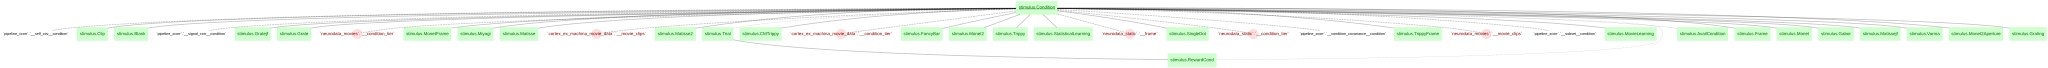

In [12]:
dj.ERD(stimulus.Condition) + 1

For example, the table `stimulus.Monet` contains parametric specification of each presentation of the Monet stimulus.

In [13]:
stimulus.Monet()

condition_hash 120-bit hash (The first 20 chars of MD5 in base64),moving_noise_version algorithm version; increment when code changes,rng_seed random number generate seed,fps display refresh rate,tex_ydim (pixels) texture dimension,tex_xdim (pixels) texture dimension,spatial_freq_half (cy/deg) spatial frequency modulated to 50 percent,"spatial_freq_stop (cy/deg), spatial lowpass cutoff",temp_bandwidth (Hz) temporal bandwidth of the stimulus,ori_on_secs seconds of movement and orientation,ori_off_secs seconds without movement,n_dirs number of directions,ori_bands orientation width expressed in units of 2*pi/n_dirs,ori_modulation mixin-coefficient of orientation biased noise,speed (degrees/s),x_degrees degrees across x if screen were wrapped at shortest distance,y_degrees degrees across y if screen were wrapped at shortest distance,directions (degrees) directions in periods of motion,onsets (s) the times of onsets of moving periods,movie actual movie
+7Zb49P9JcDZin8SHrWz,5,3.0,30.00,90,160,0.04,0.08,4.0,1.0,2.75,16,2,1.0,20.0,211.403,118.914,=BLOB=,=BLOB=,=BLOB=
+Dukhv8W0Krn+D9f5pNF,5,115.0,60.00,90,160,0.04,0.08,4.0,1.0,2.75,16,2,1.0,20.0,211.403,118.914,=BLOB=,=BLOB=,=BLOB=
+LqlMs5vHWFOgvhzDw1a,4,9.0,60.00,90,160,0.04,0.08,4.0,1.75,2.0,16,2,0.0,0.0,211.403,118.914,=BLOB=,=BLOB=,=BLOB=
+uEIi3xVY+ibExSCWapR,5,27.0,30.00,90,160,0.04,0.08,4.0,1.0,2.75,16,2,1.0,20.0,211.403,118.914,=BLOB=,=BLOB=,=BLOB=
05nZtB1cteMQkZRPtZzM,4,18.0,60.00,90,160,0.04,0.08,4.0,1.75,2.0,16,2,0.0,0.0,211.403,118.914,=BLOB=,=BLOB=,=BLOB=
0dfC8dDuoYQllA7zXVZM,5,7.0,60.00,90,160,0.04,0.08,4.0,1.0,2.75,16,2,1.0,20.0,211.403,118.914,=BLOB=,=BLOB=,=BLOB=
0e9fyxGyZfT/lgGcD+cX,5,27.0,60.00,90,160,0.04,0.08,4.0,1.0,2.75,16,2,1.0,20.0,211.403,118.914,=BLOB=,=BLOB=,=BLOB=
0IwbMokYNXCh7oZUNHK5,5,5.0,60.00,90,160,0.04,0.08,4.0,1.0,2.75,16,2,1.0,20.0,211.403,118.914,=BLOB=,=BLOB=,=BLOB=
0LzszKVq4MRmOtD2veu/,5,2.0,60.00,90,160,0.04,0.08,4.0,1.0,2.75,16,2,1.0,20.0,211.403,118.914,=BLOB=,=BLOB=,=BLOB=
0vAEpE7kIMxlN6yUXLv8,5,26.0,30.00,90,160,0.04,0.08,4.0,1.0,2.75,16,2,1.0,20.0,211.403,118.914,=BLOB=,=BLOB=,=BLOB=


For the MEI like inception loop experiments, two stimulus types are of particular importance: `stimulus.Frame` and `stimulus.Clip`.

### stimulus.Frame

`stimulus.Frame` corresponds to a presentation of a single static image on each trial.

In [15]:
stimulus.Frame()

condition_hash 120-bit hash (The first 20 chars of MD5 in base64),image_class,image_id image id,pre_blank_period (s) off duration,presentation_time (s) image duration
++0nsGPrmM7MZdBkJwSk,imagenet,1301,0.320145,0.5
++2W7El2Q44xiO3Jf89L,imagenet,7154,0.889944,0.5
++3tQPRBlpY7qJVm3iDP,imagenet,5927,0.490555,0.5
++4SfEt3NvRFdbJZOPOB,imagenet,6024,0.356411,0.5
++5NXFtdkK9JyOQYxbQv,imagenet,5649,0.746929,0.5
++6o69RX0qy4QCyTd80a,cnn_mei,85,0.355399,0.5
++7eSOA+FCEClIztb0bW,imagenet,6047,0.405718,0.5
++bWdXgL7A1Nbpm9AQVd,imagenet,5556,0.426619,0.5
++Ga6nPFZ3CtzWq40Rdj,imagenet,3232,0.369726,0.5
++GtMiE0FPv4tQTa9t4o,imagenet,3207,0.536442,0.5


Each condtion of frame presentation is associated, among other things, with **image_class** and **image_id**, and these two attributes are actually the primary key of `stimulus.StaticImage.Image` table.

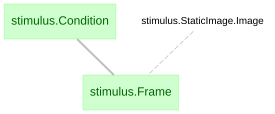

In [16]:
dj.ERD(stimulus.Frame) - 1

`stimulus.StaticImage` defines tables to store and organize collections of static images that may be presented as a `stimulus.Frame` trials. Hence, **if you want to present a new set of static images, you will have to add entries into** `stimulus.StaticImage.Image`!

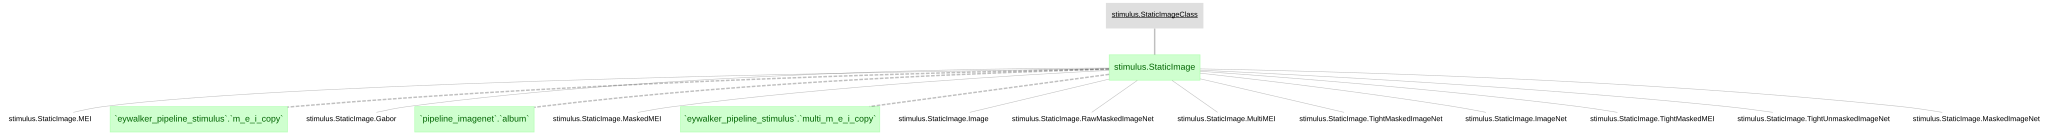

In [17]:
dj.ERD(stimulus.StaticImageClass) + 2

In fact, you can see that MEIs (and their variants such as masked MEIs) are defined as its own class of images inside `stimulus.StaticImage`.

In [21]:
stimulus.StaticImageClass() # defines classes of images

image_class
cnn_mei
gabor
gaussian_masked
gaussian_orig
imagenet
lin_rf
masked_imagenet
masked_mei
multi_cnn_mei
multi_lin_rf


In [22]:
stimulus.StaticImage() # associates specific image size and color schema (0 for BW and 1 for RGB) to each class

image_class,frame_width pixels,frame_height pixels,color whether in color or not
cnn_mei,256,144,0
gabor,256,144,0
gaussian_masked,256,144,0
gaussian_orig,256,144,0
imagenet,256,144,0
lin_rf,256,144,0
masked_imagenet,256,144,0
masked_mei,256,144,0
multi_cnn_mei,256,144,0
multi_lin_rf,256,144,0


In [25]:
stimulus.StaticImage.Image() & 'image_class = "imagenet"' # enumeration of all possible images for use in stimulus.Frame

image_class,image_id image id,image actual image
imagenet,0,=BLOB=
imagenet,1,=BLOB=
imagenet,2,=BLOB=
imagenet,3,=BLOB=
imagenet,4,=BLOB=
imagenet,5,=BLOB=
imagenet,6,=BLOB=
imagenet,7,=BLOB=
imagenet,8,=BLOB=
imagenet,9,=BLOB=


Often, you will define an additional part table under `stimulus.StaticImage` to provide additional information about the static image entries in `stimulus.StaticImage.Image`. 

In [27]:
stimulus.StaticImage.ImageNet()  # information about ImageNet images

image_class,image_id image id,imagenet_id,description image content
imagenet,0,n02808304_8892,bath_towel
imagenet,1,n02909870_6487,bucket
imagenet,2,n03393912_4860,freight_car
imagenet,3,n03447447_4729,gondola
imagenet,4,n03445777_1976,golf_ball
imagenet,5,n03085013_22368,computer_keyboard
imagenet,6,n02493509_10615,titi
imagenet,7,n02033041_5332,dowitcher
imagenet,8,n02783161_6238,ballpoint
imagenet,9,n01820546_6799,lorikeet


In [29]:
stimulus.StaticImage.MultiMEI() # information about each MEI image

image_class,image_id image id,group_id index of group,net_hash unique identifier for configuration,seed random seed,mei_param_id id,data_hash unique identifier for configuration,readout_key,neuron_id,img_config_id,x_shift shift in the width dimension,y_shift shift in the hieght dimension,src_table Table that has corresponding entries for the image
multi_cnn_mei,0,14,6d0271de31cf0a7fdd05e1e79340a471,1009,150966b4691c643986d738a5f6656594,c18c87ccb6f2b296173514c39d478360,group014-20457-5-9-0,3040,0,-1,-1,multi_mei.ShiftedMEI
multi_cnn_mei,1,14,6d0271de31cf0a7fdd05e1e79340a471,1009,150966b4691c643986d738a5f6656594,c18c87ccb6f2b296173514c39d478360,group014-20457-5-9-0,3040,0,-1,0,multi_mei.ShiftedMEI
multi_cnn_mei,2,14,6d0271de31cf0a7fdd05e1e79340a471,1009,150966b4691c643986d738a5f6656594,c18c87ccb6f2b296173514c39d478360,group014-20457-5-9-0,3040,0,-1,1,multi_mei.ShiftedMEI
multi_cnn_mei,3,14,6d0271de31cf0a7fdd05e1e79340a471,1009,150966b4691c643986d738a5f6656594,c18c87ccb6f2b296173514c39d478360,group014-20457-5-9-0,3040,0,0,-1,multi_mei.ShiftedMEI
multi_cnn_mei,4,14,6d0271de31cf0a7fdd05e1e79340a471,1009,150966b4691c643986d738a5f6656594,c18c87ccb6f2b296173514c39d478360,group014-20457-5-9-0,3040,0,0,0,multi_mei.ShiftedMEI
multi_cnn_mei,5,14,6d0271de31cf0a7fdd05e1e79340a471,1009,150966b4691c643986d738a5f6656594,c18c87ccb6f2b296173514c39d478360,group014-20457-5-9-0,3040,0,0,1,multi_mei.ShiftedMEI
multi_cnn_mei,6,14,6d0271de31cf0a7fdd05e1e79340a471,1009,150966b4691c643986d738a5f6656594,c18c87ccb6f2b296173514c39d478360,group014-20457-5-9-0,3040,0,1,-1,multi_mei.ShiftedMEI
multi_cnn_mei,7,14,6d0271de31cf0a7fdd05e1e79340a471,1009,150966b4691c643986d738a5f6656594,c18c87ccb6f2b296173514c39d478360,group014-20457-5-9-0,3040,0,1,0,multi_mei.ShiftedMEI
multi_cnn_mei,8,14,6d0271de31cf0a7fdd05e1e79340a471,1009,150966b4691c643986d738a5f6656594,c18c87ccb6f2b296173514c39d478360,group014-20457-5-9-0,3040,0,1,1,multi_mei.ShiftedMEI
multi_cnn_mei,9,14,6d0271de31cf0a7fdd05e1e79340a471,1009,150966b4691c643986d738a5f6656594,c18c87ccb6f2b296173514c39d478360,group014-20457-5-9-0,3270,0,-1,-1,multi_mei.ShiftedMEI


We will revisit the entries pertaining to the MEI later on.

### stimulus.Clip

Much like `stimulus.Frame`, `stimulus.Clip` corresponds to presentation of a movie clip per trial.

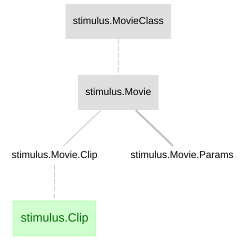

In [33]:
dj.ERD(stimulus.Clip) + stimulus.MovieClass + stimulus.Movie + stimulus.Movie.Params

In [35]:
stimulus.MovieClass() # different types of movies

movie_class
cinema
madmax
modified
mousecam
multiobjects
object3d
opticflow
unreal
varmaObj
youtube


In [37]:
stimulus.Movie()  # each "movie" entry corresponds to a collection of movie "clips"

movie_name short movie title,path,movie_class,original_file,file_template filename template with full path,file_duration (s) duration of each file (must be equal),codec,movie_description full movie title,frame_rate frames per second,frame_width pixels,frame_height pixels
bigrun,W:\UnrealVideos\bigrun1,unreal,run*.mp4,bigrun_%04u.mov,70.0,-c:v libx264 -vf format=gray -pix_fmt yuv420p -s 256:144 -preset slow -crf 10,rendered movies at various environments,30.0,256,144
c60v2,X:\Stimuli\VarmaObj\varmaobj_batch_190404,varmaObj,noise_bg60_b[-2]_*.mp4,o6060v2_%03u.mov,10.0,-c:v libx264 -vf format=gray -pix_fmt yuv420p -s 256:144 -preset slow -crf 10,rendered movies at various environments,30.0,256,144
finalrun,/scratch05/UnrealVideos/rendered_movies,unreal,*.mp4,finalrun_%05u.mov,60.0,-ss 9.966666667 -c:v libx264 -vf format=gray -pix_fmt yuv420p -s 256:144 -preset slow -crf 10,"large set of rendered. Last 60"" without the last frame",30.0,256,144
koyqatsi,H:\QATSI\KOYAANISQATSI,cinema,koyaanisqatsi_2.mp4,koyqatsi_%03u.mov,60.0,-c:v libx264 -vf format=gray -pix_fmt yuv420p -preset slow -crf 10,KOYAANISQATSI,30.0,256,144
MadMax,~/stimuli/movies/madmax,cinema,madmax.avi,madmax_%03u.mov,60.0,-c:v libx264 -vf format=gray -pix_fmt yuv420p -preset slow -crf 10,Mad Max: Fury Road (2015),30.0,256,144
matrix,H:\THE_MATRIX,cinema,matrix.mp4,matrix_%03u.mov,60.0,-c:v libx264 -vf format=gray -pix_fmt yuv420p -preset slow -crf 10,Matrix,30.0,256,144
matrixan,H:\THE_ANIMATRIX,cinema,animatrix_1.mp4,matrixan_%03u.mov,60.0,-c:v libx264 -vf format=gray -pix_fmt yuv420p -preset slow -crf 10,aniMatrix,30.0,256,144
matrixrl,H:\THE_MATRIX_RELOADED,cinema,matrix-reloaded_1.mp4,matrixrl_%03u.mov,60.0,-c:v libx264 -vf format=gray -pix_fmt yuv420p -preset slow -crf 10,Matrix reloaded,30.0,256,144
matrixrv,H:\THE_MATRIX_REVOLUTIONS,cinema,matrx_rev.mp4,matrixrv_%03u.mov,60.0,-c:v libx264 -vf format=gray -pix_fmt yuv420p -preset slow -crf 10,Matrix revolutions,30.0,256,144
mFast,V:\UnrealVideos\FlythroughTest_12-12-17,unreal,MountainFast.avi,mFast_%03u.mov,60.0,"-c:v libx264 -vf ""format=gray, lutyuv=y=gammaval(2)"" -pix_fmt yuv420p -s 256:144 -preset slow -crf 10",rendered movies,30.0,256,144


Actual movie clip is contained in the `clip` field of `stimulus.Movie.Clip` as blob.

In [39]:
stimulus.Movie.Clip()

movie_name short movie title,clip_number clip index,file_name full file name,clip,parent_file_name
bigrun,1,bigrun_0001.mov,=BLOB=,run1-AmericanDiner-1-0.mp4
bigrun,2,bigrun_0002.mov,=BLOB=,run10-templeOpen-1-0.mp4
bigrun,3,bigrun_0003.mov,=BLOB=,run100-templeOpen-1-0.mp4
bigrun,4,bigrun_0004.mov,=BLOB=,run101-AmericanDiner-1-0.mp4
bigrun,5,bigrun_0005.mov,=BLOB=,run102-ancientTomb-1-0.mp4
bigrun,6,bigrun_0006.mov,=BLOB=,run103-darkTemple-1-0.mp4
bigrun,7,bigrun_0007.mov,=BLOB=,run104-kowloon-1-0.mp4
bigrun,8,bigrun_0008.mov,=BLOB=,run105-lowPolyJungle-1-0.mp4
bigrun,9,bigrun_0009.mov,=BLOB=,run106-medievalSewer-1-0.mp4
bigrun,10,bigrun_0010.mov,=BLOB=,run107-mountainLake-1-0.mp4


## Summary

In this notebook, we took a brief look at the stimulus pipeline, focusing on static images (`stimulus.Frame`) and movies (`stimulus.Clip`). `stimulus.Trial` serves as an entry point for us to associate population response to a specific stimulus presentation as we will see in `neuro_data` pipeline next.